### State Schema With DataClasses
- When we define a LangGraph StateGraph, we use a state schema.
- The state schema represents the structure and types of data that our graph will use.
- All nodes are expected to communicate with that schema.
- LangGraph offers flexibility in how you define your state schema, accommodating various Python types and validation approaches!
- We can use the TypedDict class from python's typing module.
- It allows you to specify keys and their corresponding value types.But, note that these are type hints.
- They can be used by static type checkers (like mypy) or IDEs to catch potential type-related errors before the code is run. But they are not enforced at runtime!

In [1]:
from typing_extensions import TypedDict
from typing import Literal
from langgraph.graph import StateGraph, START, END

class TypeDictState(TypedDict):
    name:str 
    game: Literal['Cricket', 'Football', 'Hockey']

In [2]:
def play_game(state: TypeDictState):
    return {"name": state['name'] + "Wants to Play..!"}

def cricket(state: TypeDictState):
    return {"name": state['name'] + "cricket" , "game": "Cricket"}

def football(state: TypeDictState):
    return {"name": state['name'] + "football" , "game": "Football"}

def hockey(state: TypeDictState):
    return {"name": state['name'] + "hockey" , "game": "Hockey"}



In [3]:
import random
def decide_game(state: TypeDictState) -> Literal['Cricket', 'Football', 'Hockey']:
    if random.random() < 0.5:
        return "Cricket"
    else:
        return random.choice(["Football", "Hockey"])
        

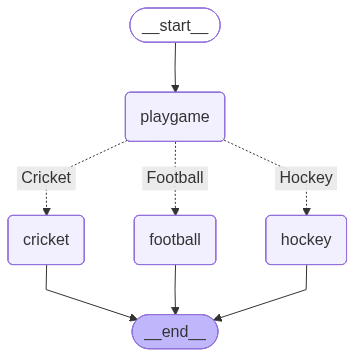

In [ ]:
from IPython.display import display,Image
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(TypeDictState)
graph_builder.add_node("playgame",play_game)
graph_builder.add_node("cricket", cricket)
graph_builder.add_node("football", football)
graph_builder.add_node("hockey", hockey)

graph_builder.add_edge(START, "playgame")

graph_builder.add_conditional_edges(
    "playgame",
    decide_game,
    # {
    #     "Cricket": "cricket",
    #     "Football": "football",
    #     "Hockey": "hockey",
    # }
)

graph_builder.add_edge("cricket", END)
graph_builder.add_edge("football", END)
graph_builder.add_edge("hockey", END)

## Add 
graph = graph_builder.compile()
 
# View
display(Image(graph.get_graph().draw_mermaid_png()))
 

In [17]:
graph.invoke({'name' : "Harry Krishna "})

{'name': 'Harry Krishna Wants to Play..!football', 'game': 'Football'}

### Dataclasses
Python's dataclasses provide another way to define structured data.

Dataclasses offer a concise syntax for creating classes that are primarily used to store data.

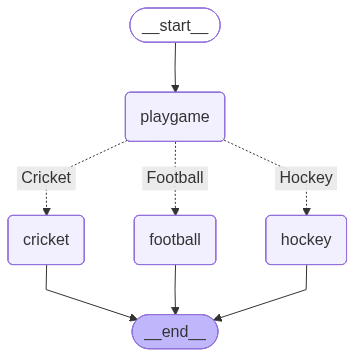

{'name': 'Harry Krishna Wants to Play..!cricket', 'game': 'Cricket'}

In [23]:
### DataClasses 
from dataclasses import dataclass
@dataclass
class DataClassState:
    name: str
    game: Literal['Cricket', 'Football', 'Hockey']

graph_builder = StateGraph(DataClassState)
graph_builder.add_node("playgame",play_game)
graph_builder.add_node("cricket", cricket)
graph_builder.add_node("football", football)
graph_builder.add_node("hockey", hockey)
graph_builder.add_edge(START, "playgame")
graph_builder.add_conditional_edges(
    "playgame",
    decide_game ,
    {
        "Cricket": "cricket",
        "Football": "football",
        "Hockey": "hockey",
    }
)
graph_builder.add_edge("cricket", END)
graph_builder.add_edge("football", END)
graph_builder.add_edge("hockey", END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({'name' : "Harry Krishna "})

In [26]:
# graph.invoke({'name' : "Harry Krishna" , 'game':"Cricket"})

graph.invoke(DataClassState(name="Harry Krishna",game="Football"))

{'name': 'Harry KrishnaWants to Play..!football', 'game': 'Football'}

In [27]:
graph.invoke(DataClassState(name=123,game="Football"))

TypeError: unsupported operand type(s) for +: 'int' and 'str'

## Pydantic Data Validation

In [36]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

class State(BaseModel):
    name: str 

In [37]:
def hello_node(state: State):
    return {"greeting": f"Hello, {state.name}!"}    

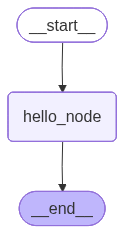

In [38]:
builder= StateGraph(State)
builder.add_node("hello_node", hello_node)
builder.add_edge(START, "hello_node")
builder.add_edge("hello_node", END)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
graph.invoke({'name' : "Harry Krishna"})

{'name': 'Harry Krishna'}

In [40]:
graph.invoke({'name' : 123})

ValidationError: 1 validation error for State
name
  Input should be a valid string [type=string_type, input_value=123, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type